# Super-Resolution on TextZoom - comparing two methods

**Computer Vision course** - University of Catania
Academic year 2025/2026 - prof. S. Battiato, F. Guarnera

| Student | Student ID | Method developed |
|---|---|---|
| Alessandro Sciacca | 1000085546 | Method 1 - HiT-SRF |
| Lorenzo Comis | 1000084704 | Method 2 - SAFMN |

A comparison between two Single Image Super-Resolution techniques, evaluated on
the same dataset, with the same adaptation protocol and the same metrics.

**Notebook structure**
- **Part 0 - Preparation**: dataset, metrics, bicubic baseline and shared functions
- **Method 1 - HiT-SRF**: model, zero-shot, fine-tuning, results
- **Method 2 - SAFMN**: model, zero-shot, fine-tuning, results

**References**
- Method 1: [HiT-SR (ECCV 2024)](https://arxiv.org/abs/2407.05878), [repo](https://github.com/XiangZ-0/HiT-SR)
- Method 2: [SAFMN (ICCV 2023)](https://arxiv.org/abs/2302.13800), [repo](https://github.com/sunny2109/SAFMN)
- Dataset: [TextZoom (ECCV 2020)](https://arxiv.org/abs/2005.03341), [repo](https://github.com/WenjiaWang0312/TextZoom)

# Part 0 - Preparation

Everything the two methods have in common: dataset, metrics, baseline and
utilities. From here on, each method only has to define its own function that,
given an LR image, returns the super-resolved image.

## 0.1 Why TextZoom and not DIV2K or Flickr2K

An earlier version of this work used DIV2K, the standard dataset for
super-resolution. Fine-tuning, however, improved almost nothing, and the reason
is simple: **HiT-SRF has already been trained by its authors on DF2K, that is
DIV2K + Flickr2K**. We were therefore re-training the model on the very data it
had already seen, and there was no room left for improvement.

Fine-tuning makes sense when the target images are **different** from the
pre-training ones. TextZoom is different in two respects:

### The LR images are real, not computer-generated

In DIV2K the LR images are obtained by downscaling the HR ones with bicubic
interpolation: a clean degradation, always identical to itself. In TextZoom, on
the contrary, **both versions were photographed**, by changing the focal length
of the camera. The LR image therefore contains real optical blur, sensor noise
and compression artifacts - things the model has never seen during training.

The authors of TextZoom stress exactly this point: their LR images are far
harder than synthetically generated ones.

### The content is of a different kind

DIV2K and Flickr2K are natural photographs: landscapes, animals, people.
TextZoom is made of text crops from signs and billboards. Text has almost
opposite visual properties:

| | Natural photos | Text |
|---|---|---|
| Edges | soft, irregular | sharp, high-contrast |
| Texture | plenty (grass, fur, clouds) | nearly absent |
| Structures | organic, variable | thin, regular strokes |

What the model has learned about natural textures is of little use when
reconstructing a letter: it has to adapt.

### There is a practical reason too

On a landscape it is hard to judge by eye whether super-resolution worked. On a
sign it is immediate: either the word can be read, or it cannot. The visual
comparison becomes far more convincing.

## 0.2 Environment setup

The notebook dependencies are installed (`lpips` for the perceptual metric,
`lmdb` to read the dataset, `timm` and `einops` required by the architectures)
and the HiT-SR repository is cloned.

In [1]:
!pip install -q timm lpips einops huggingface_hub lmdb

import os, sys, glob

# HiT-SR ships its own copy of basicsr: the repo is cloned right away
# so that the architecture is importable without installing the pip package
if not os.path.isdir('HiT-SR'):
    !git clone -q https://github.com/XiangZ-0/HiT-SR.git

sys.path.insert(0, 'HiT-SR')

import basicsr
print('basicsr caricato da:', basicsr.__file__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 346.8/346.8 kB 16.9 MB/s eta 0:00:00
basicsr caricato da: /content/HiT-SR/basicsr/__init__.py


/usr/local/lib/python3.13/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.13/dist-packages/timm/models/fx_features.py:4: FutureWarning: Importing from timm.models.fx_features is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)


Shared imports and fixed seeds, so that results are reproducible from one run
to the next.

In [2]:
import os, glob, random, time, sys, io
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt

random.seed(42)
torch.manual_seed(42)
np.random.seed(42)

device = 'cuda'
SCALE = 2                 # TextZoom is 2x scale: LR 16x64 -> HR 32x128
LR_SIZE = (64, 16)        # (width, height), the order PIL expects
HR_SIZE = (128, 32)

print(torch.cuda.get_device_name(0))

Tesla T4


## 0.3 The TextZoom dataset

TextZoom is distributed in **lmdb** format (a file-based database) through Google
Drive, and the link can be found in the [official repository](https://github.com/WenjiaWang0312/TextZoom).

1. Open the Google Drive link from the TextZoom repo
2. Download the `train2` (training) and `test/easy` (test) folders
3. Upload them to your Drive under `textzoom/`, **renaming `train2` to `train`**
   so that they match the paths used below

The next cell mounts Drive and checks that both paths exist.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

TRAIN_LMDB = '/content/drive/MyDrive/textzoom/train'
TEST_LMDB  = '/content/drive/MyDrive/textzoom/test/easy'

for path in (TRAIN_LMDB, TEST_LMDB):
    if os.path.exists(path):
        print('trovato:', path)
    else:
        print('MANCANTE:', path, '- scaricalo dalla repo di TextZoom')

Mounted at /content/drive
trovato: /content/drive/MyDrive/textzoom/train
trovato: /content/drive/MyDrive/textzoom/test/easy


### Reading the database

Each lmdb record holds three entries: the HR image, the LR image and the word
written in the image (used only for figure captions).

The images are tiny, so they are all loaded into memory once instead of being
read back from the database every time. LR images are resized to 16x64 and HR
images to 32x128, so that all sizes are uniform.

In [4]:
import lmdb


def read_lmdb(path, num_samples=None):
    """Read the lmdb and return (LR list, HR list, word list) as numpy arrays."""
    env = lmdb.open(path, readonly=True, lock=False)
    txn = env.begin()
    n = int(txn.get(b'num-samples'))
    if num_samples:
        n = min(n, num_samples)

    lr_images, hr_images, words = [], [], []
    for i in range(1, n + 1):
        lr = Image.open(io.BytesIO(txn.get(b'image_lr-%09d' % i))).convert('RGB')
        hr = Image.open(io.BytesIO(txn.get(b'image_hr-%09d' % i))).convert('RGB')
        word = txn.get(b'label-%09d' % i).decode()

        lr_images.append(np.array(lr.resize(LR_SIZE, Image.BICUBIC)))
        hr_images.append(np.array(hr.resize(HR_SIZE, Image.BICUBIC)))
        words.append(word)
    env.close()
    return lr_images, hr_images, words


train_lr, train_hr, _ = read_lmdb(TRAIN_LMDB, num_samples=3000)
# the test set is loaded in full: evaluation costs a few seconds and an average
# over ~1600 images is far more reliable than one over 200
test_lr, test_hr, test_words = read_lmdb(TEST_LMDB)

print(f'training: {len(train_lr)} coppie')
print(f'test: {len(test_lr)} coppie')
print('esempio LR:', train_lr[0].shape, '| HR:', train_hr[0].shape)

training: 2794 coppie
test: 1619 coppie
esempio LR: (16, 64, 3) | HR: (32, 128, 3)


### What the images look like

A few LR/HR pairs, to see what we are dealing with. The difference with respect
to DIV2K is immediately visible: the LR images are not simply smaller, they are
blurred and noisy, and in several cases the text is illegible.

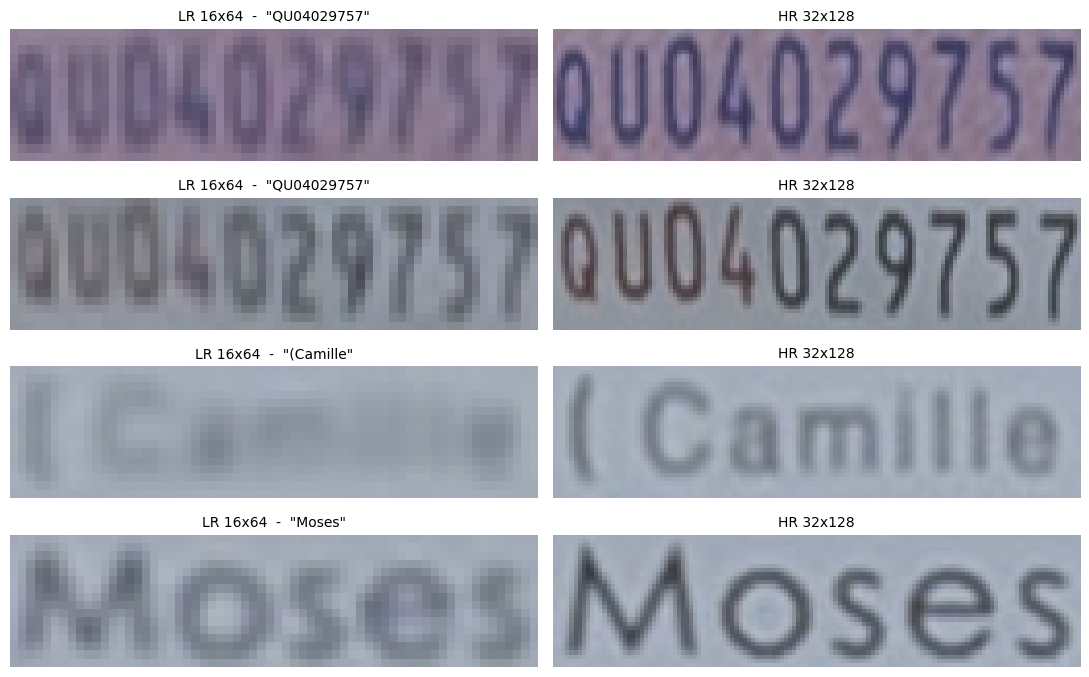

In [5]:
fig, ax = plt.subplots(4, 2, figsize=(11, 7))
for i in range(4):
    ax[i, 0].imshow(np.array(Image.fromarray(test_lr[i]).resize(HR_SIZE, Image.NEAREST)))
    ax[i, 0].set_title(f'LR 16x64  -  "{test_words[i]}"', fontsize=10)
    ax[i, 1].imshow(test_hr[i])
    ax[i, 1].set_title('HR 32x128', fontsize=10)
    ax[i, 0].axis('off'); ax[i, 1].axis('off')
plt.tight_layout(); plt.show()

## 0.4 Metrics

- **PSNR**: signal-to-noise ratio, derived from the MSE as
  `PSNR = 10 * log10(1/MSE)`. It is the standard metric in the super-resolution
  literature: reporting it makes the results readable against the usual
  references of the field. It is measured in decibels, higher is better.
- **MSE**: how much the pixels differ from the original ones. Lower is better.
  It carries the same information as the PSNR and is computed for completeness.
- **SSIM**: compares structure (edges, contrast) instead of individual pixels.
  It ranges from 0 to 1, higher is better.
- **LPIPS**: compares images using the features of a neural network, and is the
  closest one to human visual judgement. Lower is better.

Here we define the numpy-to-tensor conversions and back, and the `evaluate`
function, which runs over the whole test set and averages the metrics.

`evaluate` takes a **function** `sr_fn(lr) -> sr` as input: this way the same
evaluation serves the bicubic baseline, Method 1 and Method 2 without being
rewritten. All results end up in the `results` dictionary.

Besides the mean, `evaluate` returns the **95% confidence interval** on the mean
and keeps the per-image scores. This is what tells us when two results are
genuinely different and when the gap is just statistical noise.

In [6]:
import lpips
from skimage.metrics import structural_similarity

lpips_fn = lpips.LPIPS(net='alex').to(device)

METRICS = ['MSE', 'PSNR', 'SSIM', 'LPIPS']


def to_tensor(array):
    """numpy HxWx3 uint8 -> 1x3xHxW tensor in [0,1] on the device."""
    return torch.from_numpy(array.copy()).permute(2, 0, 1).float().div(255).unsqueeze(0).to(device)


def to_numpy(tensor):
    """1x3xHxW tensor -> numpy HxWx3."""
    return tensor[0].permute(1, 2, 0).cpu().numpy()


def compute_metrics(sr, hr):
    """MSE, PSNR, SSIM and LPIPS between two images in [0,1]."""
    a, b = to_numpy(sr), to_numpy(hr)
    mse = np.mean((a - b) ** 2)
    psnr = 10 * np.log10(1.0 / max(mse, 1e-10))
    ssim = structural_similarity(a, b, channel_axis=2, data_range=1.0, win_size=7)
    with torch.no_grad():
        lp = lpips_fn(sr * 2 - 1, hr * 2 - 1).item()
    return mse, psnr, ssim, lp


def evaluate(sr_fn, name):
    """Apply sr_fn to the whole test set and return means and confidence intervals."""
    scores = []
    for lr_np, hr_np in zip(test_lr, test_hr):
        lr, hr = to_tensor(lr_np), to_tensor(hr_np)
        sr = sr_fn(lr)
        scores.append(compute_metrics(sr, hr))

    scores = np.array(scores)                 # one row per image
    mean = scores.mean(axis=0)
    # the PSNR must be averaged per image, not derived from the mean MSE
    ci = 1.96 * scores.std(axis=0, ddof=1) / np.sqrt(len(scores))   # 95% CI on the mean

    out = {m: mean[k] for k, m in enumerate(METRICS)}
    out['CI'] = {m: ci[k] for k, m in enumerate(METRICS)}
    out['scores'] = scores                    # useful for the paired comparisons

    print(f'{name:22s}  PSNR {out["PSNR"]:.2f}+-{ci[1]:.2f}  '
          f'SSIM {out["SSIM"]:.4f}+-{ci[2]:.4f}  '
          f'LPIPS {out["LPIPS"]:.4f}+-{ci[3]:.4f}')
    return out


results = {}

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 175MB/s]


Loading model from: /usr/local/lib/python3.13/dist-packages/lpips/weights/v0.1/alex.pth


## 0.5 Baseline: bicubic interpolation

The minimum reference. If a model does not beat a plain bicubic upscaling, it is
not doing anything useful.

In [7]:
def bicubic_sr(lr):
    return F.interpolate(lr, scale_factor=SCALE, mode='bicubic').clamp(0, 1)


results['bicubic'] = evaluate(bicubic_sr, 'bicubic')

bicubic                 PSNR 23.42+-0.14  SSIM 0.7359+-0.0054  LPIPS 0.1691+-0.0045


## 0.6 Functions to display the results

Two utilities reused by both methods:
- `plot_metrics` draws the metrics as bars for the chosen entries of `results`,
  with error bars given by the 95% confidence interval
- `show_comparison` puts side by side the same image as reconstructed by several
  methods


In [8]:
def plot_metrics(keys=None, title=None, metrics=('PSNR', 'SSIM', 'LPIPS'), save=None):
    """Bar chart of the given metrics, with 95% confidence intervals."""
    keys = keys or list(results.keys())
    palette = ['#b0b0b0', '#4c72b0', '#55a868', '#c44e52', '#8172b2', '#937860']
    fig, ax = plt.subplots(1, len(metrics), figsize=(4.7 * len(metrics), 4))
    for a, metric in zip(np.atleast_1d(ax), metrics):
        values = [results[k][metric] for k in keys]
        errors = [results[k]['CI'][metric] for k in keys]
        bars = a.bar(keys, values, yerr=errors, capsize=4, color=palette[:len(keys)])
        direction = '(piu basso = meglio)' if metric in ('MSE', 'LPIPS') else '(piu alto = meglio)'
        a.set_title(f'{metric} {direction}')
        a.grid(axis='y', alpha=.3)
        a.tick_params(axis='x', labelrotation=15)
        if metric == 'PSNR':          # zero is not a sensible reference for decibels
            lo, hi = min(values), max(values)
            a.set_ylim(lo - (hi - lo) - 1, hi + (hi - lo) / 2 + 1)
        fmt = '{:.2f}' if metric == 'PSNR' else '{:.4f}'
        for bar, v, e in zip(bars, values, errors):
            a.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + e,
                   fmt.format(v), ha='center', va='bottom', fontsize=9)
    if title:
        plt.suptitle(title)
    if save:
        plt.savefig(save, dpi=150, bbox_inches='tight')
    plt.tight_layout(); plt.show()


def show_comparison(index, methods, save=None):
    """methods: dict {name: sr_fn}. Shows the bicubic LR, the outputs and the original HR."""
    lr, hr = to_tensor(test_lr[index]), to_tensor(test_hr[index])
    images = {'LR (bicubica)': bicubic_sr(lr)}
    for name, sr_fn in methods.items():
        images[name] = sr_fn(lr)
    images['HR (originale)'] = hr

    fig, ax = plt.subplots(len(images), 1, figsize=(7, 1.5 * len(images)))
    for a, (name, img) in zip(ax, images.items()):
        a.imshow(to_numpy(img)); a.set_title(name, fontsize=10); a.axis('off')
    plt.suptitle(f'parola: "{test_words[index]}"', fontsize=11)
    if save:
        plt.savefig(save, dpi=150, bbox_inches='tight')
    plt.tight_layout(); plt.show()

# Method 1 - HiT-SRF

HiT-SRF is a Transformer for super-resolution presented at **ECCV 2024**.

Transformers rely on *attention*, which relates every pixel to every other one:
powerful, but far too expensive on a whole image. The classic workaround
(SwinIR) is to compute attention only inside small windows, but then the model
always looks at a single scale.

The idea behind HiT-SR is to **let the windows grow with depth**: the first
layers use small windows (details), the later ones large windows (context). To
keep the cost from exploding, the classic attention is replaced by a mechanism
that grows linearly instead of quadratically.

It was chosen because it has fewer than **850 thousand parameters** (comparable
models have 20 million), which makes fine-tuning feasible on Colab. The **x2**
version is used, since TextZoom is at scale 2x.

**Steps of the method:** loading the model, zero-shot test, fine-tuning,
re-evaluation, visual comparison, results.

## 1.1 Loading the model

The HiT-SR repo has already been cloned in the setup cell. The architecture
configuration is read from the x2 test file provided by the authors, so that the
network parameters are exactly the ones the weights were trained with.

In [9]:
import yaml
from basicsr.archs.hit_srf_arch import HiT_SRF

config = yaml.safe_load(open('HiT-SR/options/Test/test_HiT_SRF_x2.yml'))['network_g']
config.pop('type')
print(config)

{'upscale': 2, 'in_chans': 3, 'img_size': 64, 'base_win_size': [8, 8], 'img_range': 1.0, 'depths': [6, 6, 6, 6], 'embed_dim': 60, 'num_heads': [6, 6, 6, 6], 'expansion_factor': 2, 'resi_connection': '1conv', 'hier_win_ratios': [0.5, 1, 2, 4, 6, 8], 'upsampler': 'pixelshuffledirect'}


`load_model()` with no arguments downloads (or reuses) the authors' pre-trained
weights; given a path, it loads weights stored locally, for instance those
produced by fine-tuning.

In [10]:
# the weights go on Drive: /content is wiped at every disconnection
WEIGHTS_DIR = '/content/drive/MyDrive/textzoom/weights'
os.makedirs(WEIGHTS_DIR, exist_ok=True)

BASE_WEIGHTS = os.path.join(WEIGHTS_DIR, 'HiT-SRF-2x.pth')
FT_WEIGHTS   = os.path.join(WEIGHTS_DIR, 'HiT-SRF_textzoom.pth')


def load_model(weights_path=None):
    if weights_path is None:
        if os.path.exists(BASE_WEIGHTS):
            model = HiT_SRF(**config)
            model.load_state_dict(torch.load(BASE_WEIGHTS, map_location='cpu')['params'])
        else:
            model = HiT_SRF.from_pretrained('XiangZ/hit-srf-2x')
            torch.save({'params': model.state_dict()}, BASE_WEIGHTS)
    else:
        model = HiT_SRF(**config)
        model.load_state_dict(torch.load(weights_path, map_location='cpu')['params'])
    return model.to(device)


model = load_model()
print(f'{sum(p.numel() for p in model.parameters()):,} parametri')

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.50MB            

model.safetensors: downloading bytes:           |  0.00B            

846,944 parametri


## 1.2 Zero-shot test

The model is tested as it is, with the authors' weights. This is the starting
point: without it, there would be no way to tell whether fine-tuning improved
anything.

The architecture requires images whose dimensions are multiples of 64, while the
LR images are 16x64: padding is therefore added, and the excess is cropped away
from the result.

In [11]:
def hitsr_sr(model, lr):
    """Apply HiT-SRF, handling the padding required by the architecture."""
    model.eval()
    h, w = lr.shape[2], lr.shape[3]
    pad_h, pad_w = (64 - h % 64) % 64, (64 - w % 64) % 64
    x = F.pad(lr, (0, pad_w, 0, pad_h), mode='replicate')
    with torch.no_grad():
        out = model(x)
    return out[:, :, :h * SCALE, :w * SCALE].clamp(0, 1)


lr = to_tensor(test_lr[0])
sr = hitsr_sr(model, lr)
print('LR:', tuple(lr.shape), '-> SR:', tuple(sr.shape))

/usr/local/lib/python3.13/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


LR: (1, 3, 16, 64) -> SR: (1, 3, 32, 128)


The pre-trained model is evaluated on the test set. A result close to the
bicubic baseline is expected: the network has never seen text images degraded in
a realistic way.

In [12]:
results['hitsrf-zeroshot'] = evaluate(lambda lr: hitsr_sr(model, lr), 'hitsrf-zeroshot')

hitsrf-zeroshot         PSNR 23.56+-0.14  SSIM 0.7404+-0.0056  LPIPS 0.1559+-0.0045


## 1.3 Fine-tuning

Training resumes from the pre-trained weights.

**How:**
- **L1 loss**, the same one used by the authors in their repository.
- **Low learning rate** (1e-5, against the 2e-4 of training from scratch): the
  model is already competent in general, it only has to be specialised on text
  without ruining what it already knows.
- **The whole network is trained**, not only the last layers. In classification
  one freezes most of the model and retrains only the head, but there the
  problem changes (new classes). Here the task stays the same, and what
  generates the details is spread across the whole network.
- **Whole images**, without crops: they are already tiny (16x64).

The model is seeing something genuinely new, both in content (text instead of
landscapes) and in the kind of degradation (a real photograph instead of bicubic
downscaling): this is where fine-tuning should make the difference.

In [13]:
class TextZoomDataset(Dataset):
    def __init__(self, lr_list, hr_list):
        self.lr, self.hr = lr_list, hr_list

    def __len__(self):
        return len(self.lr)

    def __getitem__(self, i):
        convert = lambda a: torch.from_numpy(a.copy()).permute(2, 0, 1).float() / 255
        return convert(self.lr[i]), convert(self.hr[i])


train_loader = DataLoader(TextZoomDataset(train_lr, train_hr), batch_size=16, shuffle=True, drop_last=True)
print(len(train_loader), 'batch per epoca')

174 batch per epoca


Training runs for 2000 iterations (about 45 minutes on a T4). If the saved
weights file is already there, training is skipped and the weights are reloaded,
so re-running the notebook costs no time.

The loss curve is saved inside the weights file itself: this way, re-running the
cell does not lose the plot.


In [14]:
from tqdm import tqdm

ITERATIONS = 2000

if os.path.exists(FT_WEIGHTS):
    print('Trovato', FT_WEIGHTS, '- carico i pesi senza riaddestrare')
    model_ft = load_model(FT_WEIGHTS)
    losses = torch.load(FT_WEIGHTS, map_location='cpu').get('losses')
else:
    model_ft = load_model()            # restart from the pre-trained weights
    model_ft.train()
    optimizer = torch.optim.Adam(model_ft.parameters(), lr=1e-5)
    criterion = nn.L1Loss()

    losses, step, t0 = [], 0, time.time()
    bar = tqdm(total=ITERATIONS)
    while step < ITERATIONS:
        for lr_batch, hr_batch in train_loader:
            if step >= ITERATIONS:
                break
            lr_batch, hr_batch = lr_batch.to(device), hr_batch.to(device)
            # same padding as at inference time: 16x64 -> 64x64
            lr_batch = F.pad(lr_batch, (0, 0, 0, 48), mode='replicate')
            output = model_ft(lr_batch)[:, :, :HR_SIZE[1], :HR_SIZE[0]]

            optimizer.zero_grad()
            loss = criterion(output, hr_batch)
            loss.backward()
            optimizer.step()

            losses.append(loss.item())
            step += 1
            bar.update(1)
            if step % 200 == 0:
                print(f'iter {step}/{ITERATIONS}  loss {np.mean(losses[-200:]):.5f} - ({(time.time() - t0) / 60:.1f} min)')
    bar.close()

    torch.save({'params': model_ft.state_dict(), 'losses': losses}, FT_WEIGHTS)
    print('Pesi salvati in', FT_WEIGHTS)


 10%|█         | 200/2000 [04:27<40:07,  1.34s/it]

iter 200/2000  loss 0.05170 - (4.5 min)


 20%|██        | 400/2000 [08:55<35:40,  1.34s/it]

iter 400/2000  loss 0.04594 - (8.9 min)


 30%|███       | 600/2000 [13:22<31:12,  1.34s/it]

...

iter 1600/2000  loss 0.03866 - (35.7 min)


 90%|█████████ | 1800/2000 [40:06<04:27,  1.34s/it]

iter 1800/2000  loss 0.03858 - (40.1 min)


100%|██████████| 2000/2000 [44:34<00:00,  1.34s/it]

iter 2000/2000  loss 0.03797 - (44.6 min)
Pesi salvati in /content/drive/MyDrive/textzoom/weights/HiT-SRF_textzoom.pth


Loss curve (moving average over 50 iterations): it is there to check that
training went down and settled, without anomalous oscillations.

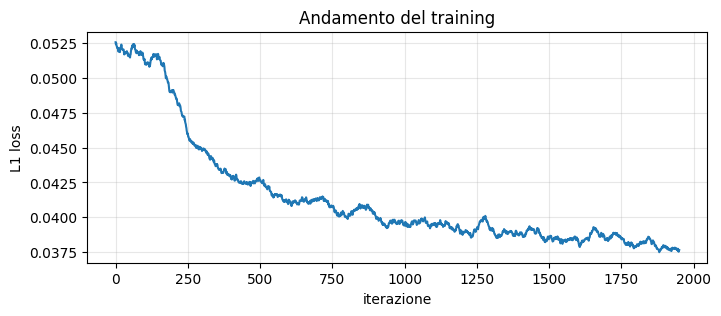

In [15]:
if losses:
    plt.figure(figsize=(8, 3))
    plt.plot(np.convolve(losses, np.ones(50) / 50, mode='valid'))
    plt.xlabel('iterazione'); plt.ylabel('L1 loss'); plt.title('Andamento del training')
    plt.grid(alpha=.3); plt.show()
else:
    print('Pesi caricati da file: nessuna curva di training da mostrare.')

Same test set, same metrics: now on the fine-tuned model.

In [16]:
results['hitsrf-finetuned'] = evaluate(lambda lr: hitsr_sr(model_ft, lr), 'hitsrf-finetuned')

hitsrf-finetuned        PSNR 25.56+-0.12  SSIM 0.8346+-0.0039  LPIPS 0.0676+-0.0025


## 1.4 Visual comparison

The four versions of the same image: the LR input upscaled bicubically, the
output before and after fine-tuning, and the original HR.

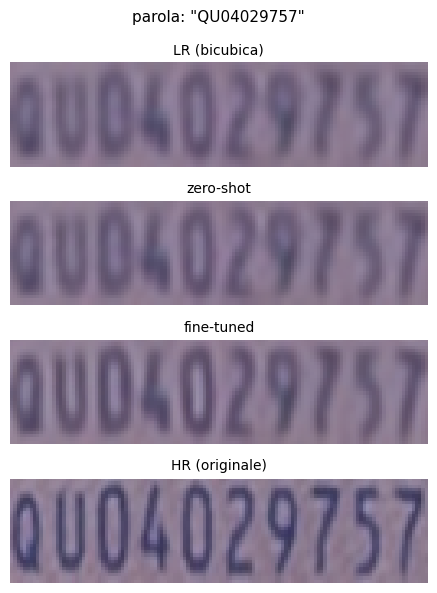

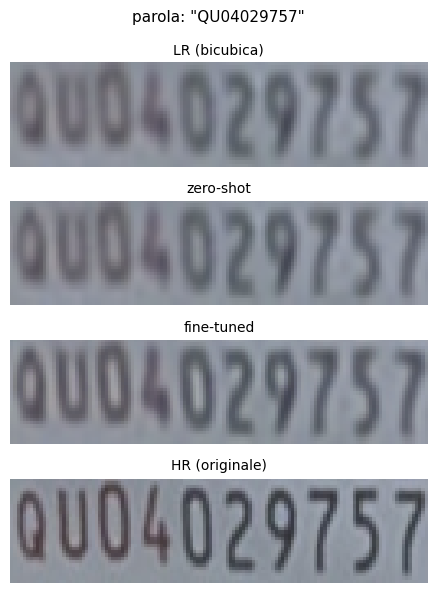

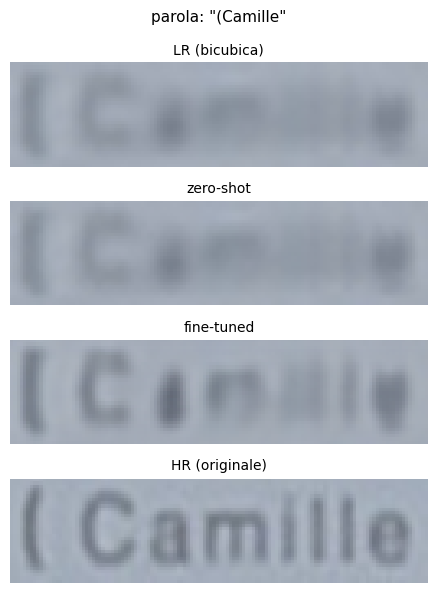

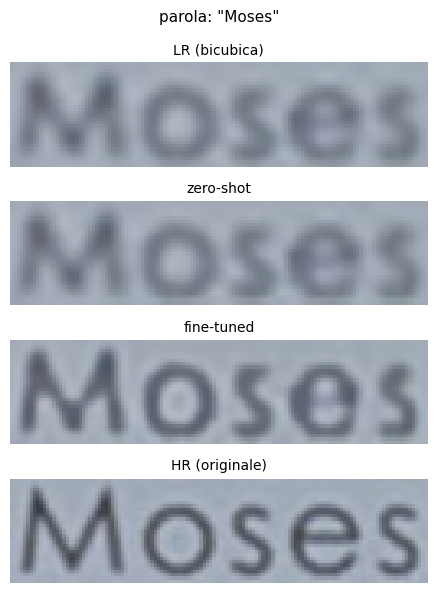

In [17]:
method1_variants = {
    'zero-shot':  lambda lr: hitsr_sr(model, lr),
    'fine-tuned': lambda lr: hitsr_sr(model_ft, lr),
}

for i in range(4):
    show_comparison(i, method1_variants)

## 1.5 Method 1 results

The three metrics side by side: bicubic, HiT-SRF zero-shot and HiT-SRF
fine-tuned.

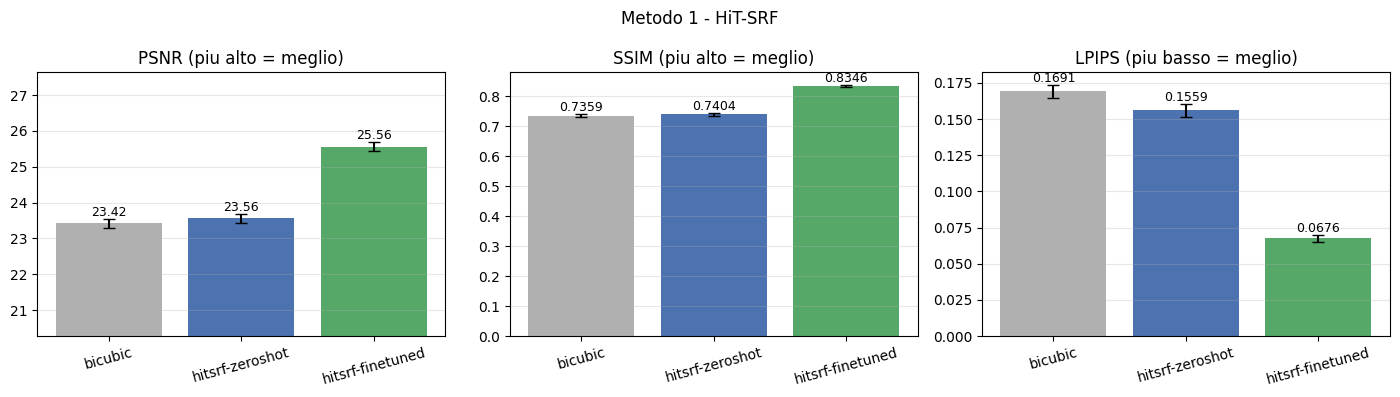

In [18]:
plot_metrics(['bicubic', 'hitsrf-zeroshot', 'hitsrf-finetuned'], title='Metodo 1 - HiT-SRF')

# Method 2 - SAFMN

SAFMN (*Spatially-Adaptive Feature Modulation*, ICCV 2023) is a **fully
convolutional** network for efficient super-resolution: no self-attention, no
Transformer-like mechanism.

The idea is to give the network a multi-scale view without paying the cost of
attention. Each block splits the features into groups and processes each group
at a different resolution - one group at full resolution for the fine details,
the others progressively downscaled for context - and then recombines them by
using the low-resolution maps to **modulate** the high-resolution ones, that is,
to decide region by region how much each feature should count. The result is a
model designed to run on mobile devices.

### Comparison of the two architectures

| | Method 1 - HiT-SRF | Method 2 - SAFMN |
|---|---|---|
| Venue | ECCV 2024 | ICCV 2023 |
| Family | Transformer | CNN |
| Long-range context | attention in hierarchical windows | multi-scale modulation |
| Pre-training | DF2K | DF2K |
| Scale | x2 | x2 |

The two models are pre-trained **on the same dataset (DF2K)**, at the same
scale, and in this notebook they are adapted to the same domain with the very
same fine-tuning recipe. The only variable that really changes is **the
architecture**: this makes it a controlled experiment, and any difference in the
results is attributable to the way the two networks process the image, not to
the data or to the protocol.

**Steps of the method:** identical to Method 1: loading the model, zero-shot
test, fine-tuning with the same recipe, re-evaluation, visual comparison,
results.

## 2.1 Loading the model

The official SAFMN repo requires `pip install basicsr`, which does not build in
the current environment. Nothing needs to be installed, though: the architecture
is **a single file** that imports PyTorch only, and the utilities it needs are
already in the copy of `basicsr` that ships with the HiT-SR repo. Only that file
is therefore downloaded and placed next to the other architectures, as one would
do with any module.

In [19]:
# SAFMN is defined in a single file, used together with the copy of basicsr
# already shipped with the HiT-SR repo
ARCH_URL = 'https://raw.githubusercontent.com/sunny2109/SAFMN/main/basicsr/archs/safmn_arch.py'
!wget -q -O HiT-SR/basicsr/archs/safmn_arch.py $ARCH_URL

from basicsr.archs.safmn_arch import SAFMN

SAFMN_URL     = 'https://huggingface.co/Meloo/SAFMN/resolve/main/SAFMN_DF2K_x2.pth'
SAFMN_WEIGHTS = os.path.join(WEIGHTS_DIR, 'SAFMN_DF2K_x2.pth')
SAFMN_FT      = os.path.join(WEIGHTS_DIR, 'SAFMN_textzoom.pth')

if not os.path.exists(SAFMN_WEIGHTS):
    !wget -q -O "$SAFMN_WEIGHTS" $SAFMN_URL


def load_safmn(weights_path=None):
    """Build SAFMN x2 by reading the configuration from the given checkpoint."""
    state = torch.load(weights_path or SAFMN_WEIGHTS, map_location='cpu')
    state = state.get('params_ema', state.get('params', state))

    # the width is the number of filters of the first convolution; the number of
    # blocks is counted from the indices of the 'feats.N....' keys
    dim = state['to_feat.weight'].shape[0]
    n_blocks = 1 + max(int(k.split('.')[1]) for k in state if k.startswith('feats.'))

    model = SAFMN(dim=dim, n_blocks=n_blocks, ffn_scale=2.0, upscaling_factor=SCALE)
    model.load_state_dict(state)
    print(f'configurazione letta dal checkpoint: dim={dim}, n_blocks={n_blocks}')
    return model.to(device)


model_sa = load_safmn()
print(f'{sum(p.numel() for p in model_sa.parameters()):,} parametri')

configurazione letta dal checkpoint: dim=36, n_blocks=8
227,820 parametri


## 2.2 Zero-shot test

As for Method 1, the model is tested with the authors' weights before any
modification.

One convenience with respect to HiT-SRF: SAFMN is fully convolutional and its
internal downscalings adapt to any size, so no padding is needed.

In [20]:
def safmn_sr(model, lr):
    """Apply SAFMN. No padding: the network accepts any input size."""
    model.eval()
    with torch.no_grad():
        out = model(lr)
    return out.clamp(0, 1)


lr = to_tensor(test_lr[0])
sr = safmn_sr(model_sa, lr)
print('LR:', tuple(lr.shape), '-> SR:', tuple(sr.shape))

LR: (1, 3, 16, 64) -> SR: (1, 3, 32, 128)


Evaluation on the test set. The expectation is the same one stated for HiT-SRF:
being pre-trained on the same synthetic degradation and on the same kind of
images, it should land close to the bicubic baseline. If that happens, it is an
independent confirmation that the problem does not lie in the individual
architecture but in the gap between the pre-training domain and the domain of
use.

In [21]:
results['safmn-zeroshot'] = evaluate(lambda lr: safmn_sr(model_sa, lr), 'safmn-zeroshot')

safmn-zeroshot          PSNR 23.57+-0.14  SSIM 0.7406+-0.0056  LPIPS 0.1579+-0.0045


## 2.3 Fine-tuning

**Exactly the same recipe as Method 1** is used: L1 loss, Adam with learning
rate 1e-5, 2000 iterations, batches of 16, the whole network unfrozen, and the
same `train_loader` already built in Part 0. The only thing that changes is the
model.

This is the condition that makes the comparison a controlled experiment: same
pre-training data, same adaptation data, same training budget, same procedure.
What is left is the architecture.

As in Method 1, the loss curve is saved inside the weights file, so re-running
the cell does not lose the plot.

In [22]:
from tqdm import tqdm

ITERATIONS = 2000

if os.path.exists(SAFMN_FT):
    print('Trovato', SAFMN_FT, '- carico i pesi senza riaddestrare')
    model_sa_ft = load_safmn(SAFMN_FT)
    losses_sa = torch.load(SAFMN_FT, map_location='cpu').get('losses')
else:
    model_sa_ft = load_safmn()          # restart from the authors' weights
    model_sa_ft.train()
    optimizer = torch.optim.Adam(model_sa_ft.parameters(), lr=1e-5)
    criterion = nn.L1Loss()

    losses_sa, step, t0 = [], 0, time.time()
    bar = tqdm(total=ITERATIONS)
    while step < ITERATIONS:
        for lr_batch, hr_batch in train_loader:
            if step >= ITERATIONS:
                break
            lr_batch, hr_batch = lr_batch.to(device), hr_batch.to(device)
            output = model_sa_ft(lr_batch)   # no padding needed

            optimizer.zero_grad()
            loss = criterion(output, hr_batch)
            loss.backward()
            optimizer.step()

            losses_sa.append(loss.item())
            step += 1
            bar.update(1)
            if step % 200 == 0:
                print(f'iter {step}/{ITERATIONS}  loss {np.mean(losses_sa[-200:]):.5f} - ({(time.time() - t0) / 60:.1f} min)')
    bar.close()

    torch.save({'params': model_sa_ft.state_dict(), 'losses': losses_sa}, SAFMN_FT)
    print('Pesi salvati in', SAFMN_FT)

configurazione letta dal checkpoint: dim=36, n_blocks=8


 10%|█         | 203/2000 [00:06<01:11, 25.04it/s]

iter 200/2000  loss 0.05195 - (0.1 min)


 20%|██        | 405/2000 [00:13<00:50, 31.62it/s]

iter 400/2000  loss 0.04861 - (0.2 min)


...

iter 1600/2000  loss 0.04296 - (0.9 min)


 90%|█████████ | 1802/2000 [01:00<00:08, 24.27it/s]

iter 1800/2000  loss 0.04247 - (1.0 min)


100%|██████████| 2000/2000 [01:07<00:00, 29.65it/s]

iter 2000/2000  loss 0.04222 - (1.1 min)
Pesi salvati in /content/drive/MyDrive/textzoom/weights/SAFMN_textzoom.pth


Loss curve, as for Method 1: it is there to verify that training went down and
settled.

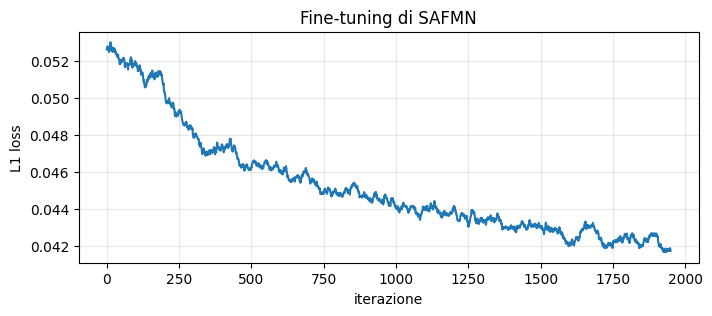

In [23]:
if losses_sa:
    plt.figure(figsize=(8, 3))
    plt.plot(np.convolve(losses_sa, np.ones(50) / 50, mode='valid'))
    plt.xlabel('iterazione'); plt.ylabel('L1 loss'); plt.title('Fine-tuning di SAFMN')
    plt.grid(alpha=.3); plt.show()
else:
    print('Nessuna curva di training disponibile.')

Same test set, same metrics, now on the fine-tuned model.

In [24]:
results['safmn-finetuned'] = evaluate(lambda lr: safmn_sr(model_sa_ft, lr), 'safmn-finetuned')

safmn-finetuned         PSNR 24.89+-0.11  SSIM 0.8157+-0.0041  LPIPS 0.0772+-0.0025


## 2.4 Visual comparison

The same four images used for Method 1, so that the two methods can be compared
by eye on the very same words.

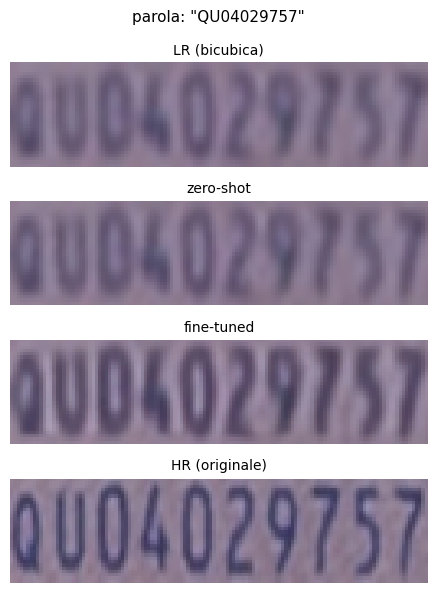

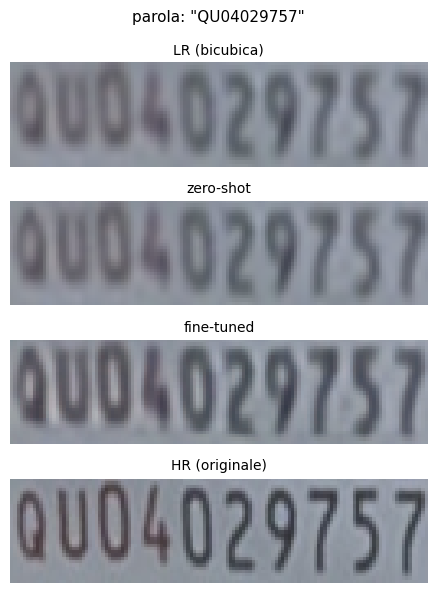

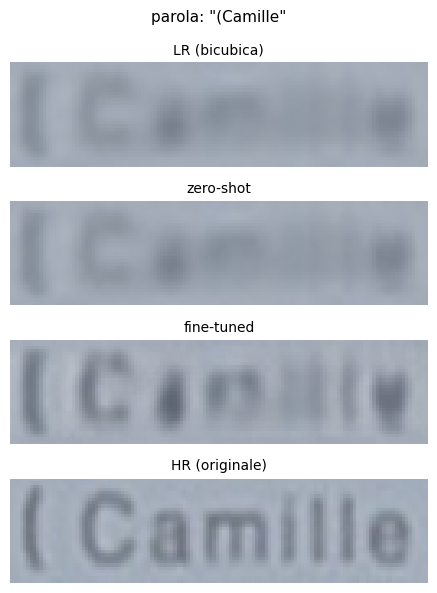

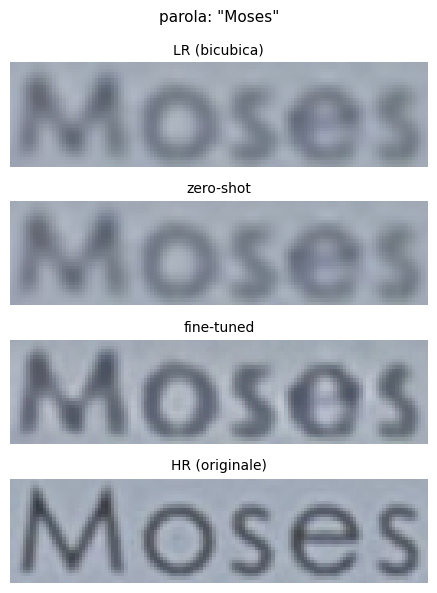

In [25]:
method2_variants = {
    'zero-shot':  lambda lr: safmn_sr(model_sa, lr),
    'fine-tuned': lambda lr: safmn_sr(model_sa_ft, lr),
}

for i in range(4):
    show_comparison(i, method2_variants)

## 2.5 Method 2 results

The three metrics side by side: bicubic, SAFMN zero-shot and SAFMN fine-tuned.

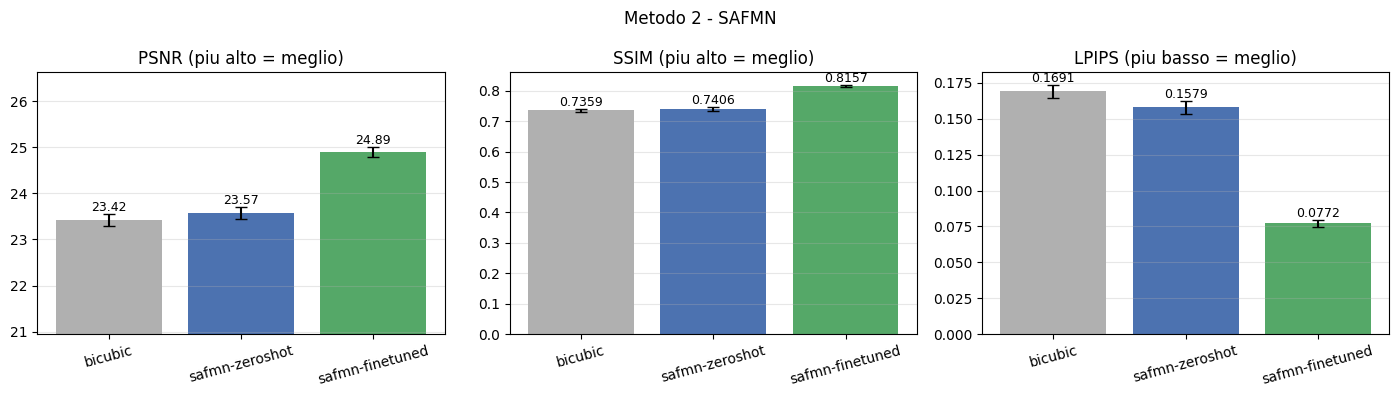

In [26]:
plot_metrics(['bicubic', 'safmn-zeroshot', 'safmn-finetuned'], title='Metodo 2 - SAFMN')

# Final comparison

The results of the two methods come from the same run, on the same test set -
the whole `easy` subset of TextZoom - and with the same metrics. The two models
are pre-trained on the same dataset (DF2K) at the same scale, and the two
fine-tunings use an identical recipe: L1 loss, Adam, learning rate 1e-5, 2000
iterations, batches of 16, the whole network unfrozen. The only variable is the
architecture.

| Model | Parameters | Training (min) | Inference (ms/img) |
|---|---|---|---|
| HiT-SRF | 846,944 | 44.6 | 173.1 |
| SAFMN | 227,820 | 1.1 | 8.2 |

| Method | PSNR (dB) | SSIM | LPIPS |
|---|---|---|---|
| Bicubic (baseline) | 23.42 ± 0.14 | 0.7359 ± 0.0054 | 0.1691 ± 0.0045 |
| HiT-SRF zero-shot | 23.56 ± 0.14 | 0.7404 ± 0.0056 | 0.1559 ± 0.0045 |
| **HiT-SRF fine-tuned** | **25.56 ± 0.12** | **0.8346 ± 0.0039** | **0.0676 ± 0.0025** |
| SAFMN zero-shot | 23.57 ± 0.14 | 0.7406 ± 0.0056 | 0.1579 ± 0.0045 |
| SAFMN fine-tuned | 24.89 ± 0.11 | 0.8157 ± 0.0041 | 0.0772 ± 0.0025 |

## 3.1 Discussion

**Zero-shot, the two architectures are indistinguishable.** 23.56 against 23.57
dB, 0.7404 against 0.7406 of SSIM: a Transformer and a CNN, which have almost
nothing in common, obtain the very same result. Since they share the
pre-training dataset but not the architecture, out of domain it is the
pre-training that decides, not the way the network is built.

**Both beat the bicubic baseline, but negligibly.** The gain is about 0.14 dB
and the paired comparison confirms that it is not due to chance.

**It is fine-tuning that produces all the value**: +2.00 dB for HiT-SRF and
+1.32 for SAFMN, that is, an order of magnitude more than what one gets by
picking a state-of-the-art model instead of an interpolation.

**After adaptation HiT-SRF wins, but by little and at a high price.** Its
advantage is 0.67 dB and it is systematic - it is better on 81% of the images -
yet it costs 21 times the inference time and 40 times the training time. SAFMN
recovers 69% of the improvement while using 5% of the compute time.

## 3.2 Conclusions

Comparing a Transformer and a CNN for super-resolution, with the same
pre-training data, the same target domain and the same adaptation procedure,
leads to three conclusions.

**On a new domain, adaptation matters far more than the architecture.** Moving
from bicubic interpolation to a state-of-the-art model, without retraining it,
is worth 0.14 dB. Adapting that same model to the domain is worth 2.

**Zero-shot, the architecture is irrelevant.** Two deeply different networks,
pre-trained on the same data, fail indistinguishably on the new domain. The
limit does not lie in how the network processes the image, but in what it has
learned to reconstruct.

**After adaptation the difference emerges, but it has to be weighed against the
cost.** HiT-SRF is systematically better, on 81% of the images, by 0.67 dB.
SAFMN obtains 69% of the same improvement at one twenty-first of the inference
cost. Which of the two is "the best" therefore depends on the criterion: for
maximum reconstruction quality, the Transformer; for any use in which compute
time matters - processing large numbers of frames, running on constrained
devices - the lightweight CNN is the more sensible choice.

### Limitations of this work

- **The timing comparison penalises HiT-SRF specifically.** The padding from
  16x64 to 64x64 is a consequence of the unusually small size of TextZoom
  images: on ordinary-sized images that extra cost would disappear and the speed
  gap would shrink. The 21x factor holds for this dataset, not as a general
  property of the two models.
- **Only the `easy` subset.** In TextZoom the LR/HR pairs are two distinct shots
  and are not pixel-aligned, and the misalignment grows with difficulty. PSNR
  and SSIM, which compare pixels at the same position, suffer from it; the
  `medium` and `hard` subsets were not evaluated.
- **Both methods belong to the regression family.** Generative models for
  super-resolution - GANs and, more recently, diffusion - were not considered:
  the former stop at 2021, the latter work at scale x4 on much larger images and
  are not trainable with the resources of this project. The comparison therefore
  concerns two ways of building the architecture, not two ways of defining the
  objective.